# Peers given the formula's symbols copy its errors: Candidate-Signature Consensus (CSC)

This notebook demos **T6-E, iteration 4**: *Candidate-Signature Consensus (CSC)*, a gold-free error score for a natural-language → first-order-logic (NL→FOL) candidate.

**What `c_csc` measures.** Take a sentence `text` and a candidate formula `fol`. Three cheap peer LLMs, all from families other than the candidate's own (pool: DeepSeek-V3.2 / Phi-4 / GPT-4.1-mini / Qwen3-235B), translate `text`. They use the dataset-E few-shot prompt **plus a list of the candidate's own predicate and constant symbols** (`Name/arity`). Then

```
c_csc(x) = 1 − share of parseable family-disjoint peers whose formula is z3-equivalent to x.fol
           (symbols matched by lowercased name + arity; no aligner)
```

Higher means more likely ERROR. The baseline **FREE-MATCHED exact** (`c_free_exact`) uses the same three peer families and the same exact z3 test, but scores their existing few-shot outputs, which were written *without* the symbol list.

**Headline result (full PRIMARY set, 354 rows).** This is a sharp negative, provisional.
- The symbol list lowers correct-row divergence: d = 0.139 vs 0.323.
- It also makes peers **copy the candidate's errors**: error endorsement e = 0.459 vs 0.173. This is *anchoring*.
- Net: stratified AUROC is 0.614 for CSC vs 0.770 for FREE exact.

**What this notebook does.** It re-runs the artifact's $0 pipeline stages (`score` → `analyse`) on a 100-row stratified subset of PRIMARY. Each row carries its cached peer generations, so no LLM calls are made:
1. It re-derives `c_csc` and `c_free_exact` with the original z3 code (`src/csc.py` plus the vendored dataset-E parser).
2. It checks the re-derived scores against the stored ones.
3. It computes e / d / stratified AUROC with sentence-cluster bootstrap CIs.
4. It plots CSC against the baselines.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

In [2]:
# --- original imports (src/csc.py, method.py, vendor/e8src/vendor_e/fol.py, vendor/ev2/stats.py) ---
from __future__ import annotations

import hashlib
import json
import os
import random
import re
import signal
import sys
import time
from collections import defaultdict
from itertools import combinations
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import z3
from loguru import logger
from scipy.stats import rankdata

# --- additional imports for the notebook (tables + plots) ---
import pandas as pd
import matplotlib.pyplot as plt

sys.setrecursionlimit(20000)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_StxQVNnY7aQW/round-4/experiment-9/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["population"])
print("examples:", len(data["examples"]))
print("keys per example:", list(data["examples"][0].keys()))

100-row stratified subset (stratum x label) of PRIMARY = 354 R_AB rows whose 3 CSC peer calls completed
examples: 100
keys per example: ['row_key', 'sentence_id', 'stratum', 'system', 'family', 'text', 'candidate_fol', 'y', 'final_label', 'label_tier', 'error_ops', 'words', 'n_quant', 'depth', 'n_conditions', 'csc_peers', 'free_peers', 'stored']


## Pipeline entry point (`method.py`)

In the artifact, `method.py` is a stage runner. It calls each stage script under `src/` as a subprocess, with `PYTHONHASHSEED=0` and a 20 GB RAM cap. Its stage map and logger setup are copied below.

The notebook does **not** start the subprocesses, because the stage scripts read the full on-disk run. It runs the two $0 stages that matter for the headline inline instead:
- **`score`** (`src/score.py → csc.consensus_score`): the "Scoring" section below;
- **`analyse`** (`src/analyse.py`, using `vendor/ev2/stats.py`): the "Analysis" section below.

The API stages (`prep pilot prereg mini full`) are replaced by the cached peer generations stored in `mini_demo_data.json`.

In [5]:
STAGES = {"prep": ["src/prep.py"], "pilot": ["src/pilot.py"], "prereg": ["src/gen.py", "prereg"], "mini": ["src/gen.py", "mini"],
          "full": ["src/gen.py", "full"], "repro": ["src/repro.py"], "score": ["src/score.py"], "analyse": ["src/analyse.py"],
          "posthoc": ["src/posthoc_contam.py"], "report": ["src/report.py"], "audit": ["src/audit_rederive.py"], "audit_extra": ["src/audit_rederive.py", "extra"], "test": ["-m", "pytest", "-q", "-c", "pytest.ini", "tests"]}

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# (the original also adds a rotating file sink logs/method.log; omitted in the notebook)

for st, cmd in STAGES.items():
    print(f"{st:12s} -> {' '.join(cmd)}")

prep         -> src/prep.py
pilot        -> src/pilot.py
prereg       -> src/gen.py prereg
mini         -> src/gen.py mini
full         -> src/gen.py full
repro        -> src/repro.py
score        -> src/score.py
analyse      -> src/analyse.py
posthoc      -> src/posthoc_contam.py
report       -> src/report.py
audit        -> src/audit_rederive.py
audit_extra  -> src/audit_rederive.py extra
test         -> -m pytest -q -c pytest.ini tests


## Configuration

These are all the tunable parameters. The original values are noted in the comments.
- `N_EXAMPLES`: how many of the 100 demo rows to score. The artifact scored the full PRIMARY set of 354 rows; the demo file holds a stratified 100-row subset.
- `Z3_TIMEOUT_MS` / `Z3_CAP_S`: the z3 per-pair timeout and a hard wall-clock cap. A z3 UNKNOWN counts as *not equivalent*.
- `K_PEERS`: the number of family-disjoint peers.
- `N_BOOT`: the number of sentence-cluster bootstrap replicates.
- `ENDORSE_THRESHOLD`: a peer rule *endorses* the candidate when `c <= 0.5`.

In [6]:
N_EXAMPLES = 100          # rows of mini_demo_data.json to score (original: all 354 PRIMARY rows; demo file holds 100)
Z3_TIMEOUT_MS = 2000      # z3 timeout per equivalence check (original: 2000 ms)
Z3_CAP_S = 20             # hard SIGALRM cap per pair (original: 20 s)
K_PEERS = 3               # family-disjoint peers per candidate (original: 3)
N_BOOT = 2000             # sentence-cluster bootstrap replicates (original: B = 2000)
BOOT_SEED = 0             # bootstrap seed (original: numpy default_rng(0))
ENDORSE_THRESHOLD = 0.5   # en_c = (c <= 0.5) (original analyse.py rule)

## Vendored dependencies: the dataset-E FOL parser, z3 equivalence and the random-model fingerprint

`src/csc.py` imports three vendored modules from an earlier experiment:
- `vendor_e.fol as EFOL`: the Unicode FOL parser, and the translation of formulas to z3;
- `peer_text as PT`: `parse_fol` and `canon` (alpha-normalised canonical strings);
- `repair_census as RC`: `symbols` and `fp`, a 24-seed random finite-model fingerprint used as a fast *necessary* condition for equivalence.

The functions that CSC needs are copied **verbatim** below and wrapped in namespaces with the same names (`EFOL`, `PT`, `RC`), so the `csc.py` code further down runs unchanged.

`fp` uses Python's `hash()`, which is why the artifact pins `PYTHONHASHSEED=0`. A different seed only changes *which* random models are tried. A fingerprint mismatch still proves non-equivalence, so the verdicts do not depend on the seed.

In [7]:
# ============================================================ vendor/e8src/vendor_e/fol.py (verbatim excerpt)
TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
IDENT = re.compile(r"^[A-Za-z_][A-Za-z0-9_'\-]*$")
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}  # FIX (gen_art_dataset_1): ⊕ moved to the ∨ level, binds tighter than →


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("<->", "↔").replace("->", "→").replace("&", "∧").replace("|", "∨")  # FIX: <-> before ->
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if name is None or not IDENT.match(name):  # FIX (gen_art_dataset_1): truncated input used to yield atom None
            raise ValueError(f"expected identifier, got {name!r}")
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            if any(a is None or not IDENT.match(a) for a in args):
                raise ValueError(f"bad argument list {args!r}")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def _efol_parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)


EFOL = SimpleNamespace(parse=_efol_parse, equivalent=equivalent, preds=preds)

In [8]:
# ============================================================ vendor/e8src/peer_text.py (verbatim excerpt: parse & print)
BINSYM = {"iff": "↔", "xor": "⊕", "imp": "→", "or": "∨", "and": "∧"}


def parse_fol(s: str | None):
    '''Dataset-E parser. Returns the AST or None (unparseable = coverage failure, never silently dropped).'''
    if s is None or not str(s).strip():
        return None
    try:
        return EFOL.parse(str(s))
    except (ValueError, IndexError, RecursionError, TypeError):
        return None


def to_str(e) -> str:
    '''Fully parenthesised Unicode rendering; parse_fol(to_str(e)) == e.'''
    k = e[0]
    if k == "atom":
        return f"{e[1]}({', '.join(e[2])})" if e[2] else e[1]
    if k in ("all", "ex"):
        return f"{'∀' if k == 'all' else '∃'}{e[1]} ({to_str(e[2])})"
    if k == "not":
        return f"¬({to_str(e[1])})" if e[1][0] not in ("atom", "not") else f"¬{to_str(e[1])}"
    return f"({to_str(e[1])} {BINSYM[k]} {to_str(e[2])})"


def alpha(e, env=None, ctr=None):
    '''Alpha-normalise bound variables to v0, v1, ... in order of their binders (canonical strings; unique binders).'''
    env = {} if env is None else env
    ctr = [0] if ctr is None else ctr
    k = e[0]
    if k == "atom":
        return ("atom", e[1], tuple(env.get(a, a) for a in e[2]))
    if k in ("all", "ex"):
        nv = f"v{ctr[0]}"
        ctr[0] += 1
        return (k, nv, alpha(e[2], {**env, e[1]: nv}, ctr))
    if k == "not":
        return ("not", alpha(e[1], env, ctr))
    return (k, alpha(e[1], env, ctr), alpha(e[2], env, ctr))


def canon(e) -> str:
    return to_str(alpha(e))


PT = SimpleNamespace(parse_fol=parse_fol, to_str=to_str, alpha=alpha, canon=canon)


# ============================================================ vendor/e8src/vendor_c/repair_census.py (verbatim excerpt)
def atoms(e, acc=None):
    acc = [] if acc is None else acc
    if e[0] == "atom":
        acc.append(e)
    elif e[0] in ("all", "ex"):
        atoms(e[2], acc)
    elif e[0] == "not":
        atoms(e[1], acc)
    else:
        atoms(e[1], acc); atoms(e[2], acc)
    return acc


def bound_vars(e, acc=None):
    acc = set() if acc is None else acc
    if e[0] in ("all", "ex"):
        acc.add(e[1]); bound_vars(e[2], acc)
    elif e[0] == "not":
        bound_vars(e[1], acc)
    elif e[0] != "atom":
        bound_vars(e[1], acc); bound_vars(e[2], acc)
    return acc


def symbols(e):
    bv = bound_vars(e)
    P, C = {}, set()
    for a in atoms(e):
        P[(a[1], len(a[2]))] = True
        for x in a[2]:
            if x not in bv:
                C.add(x)
    return set(P), C


# ---------------------------------------------------------------- random-model fingerprint (necessary condition)
SEEDS = list(range(24))


def ev(e, m, env, dom, seed):
    k = e[0]
    if k == "atom":
        args = tuple(env[x] if x in env else (hash((seed, "c", x)) % dom) for x in e[2])
        return (hash((seed, e[1], len(e[2]), args)) >> 3) & 1 == 1
    if k == "all":
        return all(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "ex":
        return any(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "not":
        return not ev(e[1], m, env, dom, seed)
    a, b = ev(e[1], m, env, dom, seed), ev(e[2], m, env, dom, seed)
    return {"and": a and b, "or": a or b, "imp": (not a) or b, "iff": a == b, "xor": a != b}[k]


def fp(e):
    return tuple(ev(e, None, {}, 3, s) for s in SEEDS)


RC = SimpleNamespace(symbols=symbols, fp=fp)
print("parser test:", PT.canon(PT.parse_fol("∀x (Dog(x) → ∃y (Owns(y, x)))")))

parser test: ∀v0 ((Dog(v0) → ∃v1 (Owns(v1, v0))))


## CSC library, part 1: the peer pool and the family-disjoint rule (`src/csc.py`)

- `POOL` lists the four cheap peer models.
- `peers_for(cand_family, k)` takes the first *k* members whose vendor family differs from the candidate's. A peer never shares the candidate's family.
- `B_SIG` is the extra prompt block that hands the peers the candidate's own symbol list. This block is the one design choice that turns out to cause **anchoring**.

In [9]:
B_SIG = ("Symbols from another translation of this sentence (name/arity, random order): {sig}. Use a listed symbol "
         "wherever its name fits what the sentence says, and keep its arity. If part of the sentence is not covered by "
         "any listed symbol, introduce a new symbol. You need not use every listed symbol. The list is not a translation: "
         "translate the sentence itself. Return JSON {{\"fol\": <formula>, \"alt_fol\": <a formula for a second "
         "legitimate reading, or null>}}.")
# FORMAT-ONLY control: the same output instruction, no symbol list (isolates the signature from the format change)
B_FMT = ("Translate the sentence itself. Return JSON {\"fol\": <formula>, \"alt_fol\": <a formula for a second "
         "legitimate reading, or null>}.")
POOL = [("deepseek/deepseek-v3.2", "deepseek", {"reasoning": {"enabled": False}}),
        ("microsoft/phi-4", "microsoft", {}),
        ("openai/gpt-4.1-mini", "openai", {}),
        ("qwen/qwen3-235b-a22b-2507", "qwen", {})]
FAMILY_RULES = [("gpt-", "openai"), ("openai/", "openai"), ("malls_gpt4", "openai"), ("llama", "meta"), ("qwen", "qwen"),
                ("mistral", "mistral"), ("deepseek", "deepseek"), ("gemma", "google"), ("gemini", "google"),
                ("phi", "microsoft"), ("command", "cohere"), ("cohere", "cohere"), ("ccg2lambda", "symbolic")]


# =================================================================================================== families / peers
def family_of(system: str) -> str:
    '''Vendor family of an E system string (gpt-* -> openai, llama -> meta, gemma/gemini -> google, ...).'''
    s = system.lower()
    for key, fam in FAMILY_RULES:
        if key in s:
            return fam
    return "other:" + s


def peers_for(cand_family: str, k: int = 3) -> list[tuple[str, str, dict]]:
    '''First k members of POOL whose family differs from the candidate's (family-disjoint; never the candidate's own).'''
    return [m for m in POOL if m[1] != cand_family][:k]


for fam in ("qwen", "openai", "meta"):
    print(f"candidate family {fam:8s} -> peers {[m[0] for m in peers_for(fam, K_PEERS)]}")

candidate family qwen     -> peers ['deepseek/deepseek-v3.2', 'microsoft/phi-4', 'openai/gpt-4.1-mini']
candidate family openai   -> peers ['deepseek/deepseek-v3.2', 'microsoft/phi-4', 'qwen/qwen3-235b-a22b-2507']
candidate family meta     -> peers ['deepseek/deepseek-v3.2', 'microsoft/phi-4', 'openai/gpt-4.1-mini']


## CSC library, part 2: signature extraction, prompt construction and response parsing

- `extract_signature` reads the candidate's predicate and constant symbols (lowercased name, arity, original casing).
- `order_symbols` shuffles them with a seed derived from `(text, signature)`, so the same input always produces the same prompt bytes.
- `build_prompt` appends `B_SIG` to the dataset-E few-shot prompt. In the notebook, `load_prompt` reads that prompt from the data file instead of from `vendor/data/prompts/fewshot_v1.txt`; this is the only change in this cell.
- `parse_response` robustly pulls `{fol, alt_fol}` out of the raw peer text.

In [10]:
# =================================================================================================== parsing / signature
def parse(s: str | None):
    return PT.parse_fol(s)


def extract_signature(fol: str | None) -> list[tuple[str, int, str]] | None:
    '''Predicate symbols with arity plus constants (arity 0) of `fol`, read by the dataset-E parser.
    Returns a sorted list of (lowercased name, arity, original-casing name) -- one entry per (lowercased name, arity),
    the first original casing in sorted order kept -- or None if unparseable. Variables, connectives and quantifiers are
    excluded; an argument that is not bound by a quantifier is a constant (E-parser convention).'''
    e = parse(fol)
    if e is None:
        return None
    P, C = RC.symbols(e)
    out = {}
    for name, ar in sorted(P):
        out.setdefault((name.lower(), ar), name)
    for c in sorted(C):
        out.setdefault((c.lower(), 0), c)
    return sorted((k[0], k[1], v) for k, v in out.items())


def canonical_sig(sig: list) -> str:
    return ",".join(f"{n}/{a}" for n, a, _ in sorted(sig))


def order_symbols(text: str, sig: list) -> list[str]:
    '''Name/arity strings in the candidate's original casing, shuffled by
    random.Random(int(sha1(text + '|' + canonical_sorted_sig), 16)) -> same (text, signature) = same prompt bytes.'''
    items = [f"{orig}/{a}" for _, a, orig in sorted(sig)]
    rng = random.Random(int(hashlib.sha1((text + "|" + canonical_sig(sig)).encode()).hexdigest(), 16))
    rng.shuffle(items)
    return items


def load_prompt() -> dict:
    # original: json.loads(PROMPT_PATH.read_text()) with PROMPT_PATH = vendor/data/prompts/fewshot_v1.txt
    return data["prompt_fewshot_v1"]


def build_prompt(text: str, sig_list: list[str] | None, fmt_only: bool = False) -> list[dict]:
    '''dataset-E fewshot_v1 messages byte-identical + one appended block in the final user message.
    sig_list=None and fmt_only=True -> FORMAT-ONLY control block (no symbols).'''
    pr = load_prompt()
    user = pr["user_template"].format(sentence=text)
    if fmt_only:
        user += "\n\n" + B_FMT
    else:
        user += "\n\n" + B_SIG.format(sig=", ".join(sig_list or []))
    return [{"role": "system", "content": pr["system"]}] + pr["exemplars"] + [{"role": "user", "content": user}]


def prompt_key(model: str, messages: list[dict]) -> str:
    return hashlib.sha1((model + "|" + json.dumps(messages, ensure_ascii=False, sort_keys=True)).encode()).hexdigest()


_FORMULA_CH = re.compile(r"[∀∃¬∧∨→↔⊕]|\w+\(")


def parse_response(raw: str | None) -> dict:
    '''Peer JSON {fol, alt_fol} -> dict with 'route'. Routes: json | json_fenced | json_regex | fol_line | formula_line | none.'''
    s = (raw or "").strip()
    if not s:
        return {"fol": None, "alt_fol": None, "route": "none"}
    cand = [("json", s)]
    m = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", s, re.S)
    if m:
        cand.append(("json_fenced", m.group(1)))
    m = re.search(r"\{.*\}", s, re.S)
    if m:
        cand.append(("json_regex", m.group(0)))
    for route, t in cand:
        try:
            d = json.loads(t)
        except (json.JSONDecodeError, ValueError):
            continue
        if isinstance(d, dict) and "fol" in d:
            f = d.get("fol")
            a = d.get("alt_fol")
            f = f.strip() if isinstance(f, str) and f.strip() else None
            a = a.strip() if isinstance(a, str) and a.strip() and a.strip().lower() not in ("null", "none") else None
            return {"fol": f, "alt_fol": a, "route": route}
    for line in s.splitlines():  # few-shot format leakage 'FOL: ...'
        if line.strip().startswith("FOL:"):
            return {"fol": line.split("FOL:", 1)[1].strip(), "alt_fol": None, "route": "fol_line"}
    for line in s.splitlines():
        if _FORMULA_CH.search(line) and not line.strip().startswith("{"):
            return {"fol": line.strip().strip("`"), "alt_fol": None, "route": "formula_line"}
    return {"fol": None, "alt_fol": None, "route": "none"}

### What a CSC peer actually sees

For one demo row, the next cell prints:
- the candidate's signature;
- the seeded symbol order;
- the final user message of the peer prompt, which is the dataset-E few-shot prompt plus the `B_SIG` block.

It also checks `parse_response` on the three raw formats peers commonly return.

In [11]:
ex0 = data["examples"][0]
sig0 = extract_signature(ex0["candidate_fol"])
print("TEXT     :", ex0["text"])
print("CANDIDATE:", ex0["candidate_fol"], f"  [label={ex0['final_label']}, family={ex0['family']}]")
print("SIGNATURE:", sig0)
print("ORDERED  :", order_symbols(ex0["text"], sig0))
msgs = build_prompt(ex0["text"], order_symbols(ex0["text"], sig0))
print(f"\nprompt has {len(msgs)} messages; final user message:\n" + "-" * 80)
print(msgs[-1]["content"])
print("-" * 80)
print("prompt_key (cache key) for the first peer:", prompt_key(peers_for(ex0["family"], K_PEERS)[0][0], msgs))
for raw in ['{"fol": "∀x (A(x) → B(x))", "alt_fol": null}', '```json\n{"fol": "∃x A(x)", "alt_fol": "null"}\n```', "FOL: ∀x (A(x) ∧ B(x))"]:
    print("parse_response:", parse_response(raw))

TEXT     : Taylor is Emily's friend.
CANDIDATE: Friend(taylor, emily)   [label=ERROR, family=google]
SIGNATURE: [('emily', 0, 'emily'), ('friend', 2, 'Friend'), ('taylor', 0, 'taylor')]
ORDERED  : ['Friend/2', 'taylor/0', 'emily/0']

prompt has 14 messages; final user message:
--------------------------------------------------------------------------------
Sentence: Taylor is Emily's friend.

Symbols from another translation of this sentence (name/arity, random order): Friend/2, taylor/0, emily/0. Use a listed symbol wherever its name fits what the sentence says, and keep its arity. If part of the sentence is not covered by any listed symbol, introduce a new symbol. You need not use every listed symbol. The list is not a translation: translate the sentence itself. Return JSON {"fol": <formula>, "alt_fol": <a formula for a second legitimate reading, or null>}.
--------------------------------------------------------------------------------
prompt_key (cache key) for the first peer: 8a41

## CSC library, part 3: same-vocabulary z3 equivalence

- `_norm` lowercases predicate names and turns constants into `k_<name>`, so symbols are identified by lowercased name and arity only.
- `_eq_canon` short-circuits on identical canonical strings. It then applies the random-model fingerprint (`RC.fp`), a sound necessary condition, and only after that calls z3 with a 2 s timeout.
- A timeout, an exception or a pathological formula gives `None` (UNKNOWN). UNKNOWN is counted, and is scored as not equivalent.

In [12]:
# =================================================================================================== same-vocabulary equivalence
def _norm(e, bound=frozenset()):
    '''Case-normalise symbols: predicate names -> lowercase; constants -> 'k_' + lowercase (cannot capture a bound
    variable). Arity stays part of a predicate's identity (z3 keys 'name/arity').'''
    k = e[0]
    if k == "atom":
        return ("atom", e[1].lower(), tuple(a if a in bound else "k_" + a.lower() for a in e[2]))
    if k in ("all", "ex"):
        return (k, e[1], _norm(e[2], bound | {e[1]}))
    if k == "not":
        return ("not", _norm(e[1], bound))
    return (k, _norm(e[1], bound), _norm(e[2], bound))


def norm_canon(fol: str | None) -> str | None:
    '''Canonical (alpha-normalised, case-normalised) string of a formula, or None if unparseable.'''
    e = parse(fol)
    return None if e is None else PT.canon(_norm(e))


class _TO(Exception):
    pass


def _alarm(signum, frame):  # noqa: ARG001
    raise _TO()


def exact_equiv(a: str | None, b: str | None, timeout_ms: int = Z3_TIMEOUT_MS, cap_s: int = Z3_CAP_S) -> bool | None:
    '''z3 equivalence with symbols identified by (lowercased name, arity); union vocabulary as uninterpreted symbols.
    Unlike consensus_lib 'exact' this does NOT require identical signatures (a formula using a symbol the other lacks
    is equivalent only if that symbol is logically idle). True / False / None (UNKNOWN: z3 timeout or cap).'''
    ca, cb = norm_canon(a), norm_canon(b)
    if ca is None or cb is None:
        return None
    return _eq_canon(ca, cb, timeout_ms, cap_s)


_EQ_CACHE: dict = {}


def _eq_canon(ca: str, cb: str, timeout_ms: int = Z3_TIMEOUT_MS, cap_s: int = Z3_CAP_S) -> bool | None:
    if ca == cb:
        return True
    key = (ca, cb) if ca < cb else (cb, ca)
    if key in _EQ_CACHE:
        return _EQ_CACHE[key]
    ea, eb = EFOL.parse(ca), EFOL.parse(cb)
    use_alarm = hasattr(signal, "SIGALRM")
    try:
        if use_alarm:
            old = signal.signal(signal.SIGALRM, _alarm)
            signal.alarm(cap_s)
        try:
            if RC.fp(ea) != RC.fp(eb):  # sound necessary condition (random finite models)
                r = False
            else:
                r = EFOL.equivalent(ea, eb, ms=timeout_ms)
        finally:
            if use_alarm:
                signal.alarm(0)
                signal.signal(signal.SIGALRM, old)
    except (_TO, RecursionError, Exception):  # noqa: BLE001 - z3 exceptions / pathological formulas -> UNKNOWN (counted)
        r = None
    if len(_EQ_CACHE) > 200000:
        _EQ_CACHE.clear()
    _EQ_CACHE[key] = r
    return r


# quick sanity checks: case-insensitive names, De Morgan, scope error
print(exact_equiv("∀x (Dog(x) → Animal(x))", "∀y (dog(y) → animal(y))"))          # True  (renamed var + case)
print(exact_equiv("¬(A(x0) ∧ B(x0))", "¬A(x0) ∨ ¬B(x0)"))                          # True  (De Morgan, constants)
print(exact_equiv("∀x ∃y Loves(x, y)", "∃y ∀x Loves(x, y)"))                        # False (quantifier scope)

True
True
False


## CSC library, part 4: consensus scores

`consensus_score(cand_fol, peer_outs)` returns `c_csc`, which is 1 − (share of usable peers exactly equivalent to the candidate). It also returns `c_csc_multi`, where a peer's `alt_fol` counts as endorsement if a second peer also produces that reading.

Failures are never silent:
- an unparseable candidate scores 1.0;
- fewer than 2 usable peers scores 0.5;
- UNKNOWN verdicts are counted.

**Notebook note.** The graded variant `c_csc_graded` needs the claim-unit entailer from `peer_text` (`Entailer`, `units_of`, `graded_consensus`, about 600 more vendored lines). That code is not vendored here, so the notebook calls `consensus_score(..., graded=False)`. The stored `c_csc_graded` values from the full run are shown for reference instead. The graded code path below is otherwise unchanged. `majority_formula` is copied verbatim.

In [13]:
# =================================================================================================== consensus scores
def _identity_pair(cand_s: str, peer_s: str, ent) -> dict:
    '''pair_result record for graded_consensus with the IDENTITY vocabulary map (strings already case-normalised).'''
    cu_s = PT.units_of(cand_s)[0]
    pu_s = PT.units_of(peer_s)[0]
    fwd = [ent(peer_s, u) for u in cu_s]
    bwd = [ent(cand_s, v) for v in pu_s]
    eq = _eq_canon(cand_s, peer_s)
    return {"fwd": fwd, "bwd": bwd, "peer_r": peer_s, "peer_units_r": list(pu_s), "equiv": eq, "cost": 0.0, "n_maps": 1, "rank": 0}


def consensus_score(cand_fol: str | None, peer_outs: list[dict], modes=("csc", "csc_graded", "csc_multi"),
                    timeout_ms: int = Z3_TIMEOUT_MS, graded: bool = True) -> dict:
    '''Score candidate `cand_fol` against peer outputs [{'fol': str|None, 'alt_fol': str|None, 'model': ...}, ...].

    Returns {'status', 'n_peers', 'n_usable', 'n_unparseable_peers', 'n_unknown', 'per_peer' (True/False/None),
             'c_csc', 'c_csc_graded', 'c_csc_multi', 'unit_codes', 'secs'} (all scores oriented higher = more likely error).'''
    t0 = time.time()
    cs = norm_canon(cand_fol)
    usable = []
    n_bad = 0
    for p in peer_outs:
        c = norm_canon(p.get("fol"))
        if c is None:
            n_bad += 1
            continue
        usable.append({"c": c, "alt": norm_canon(p.get("alt_fol")) if p.get("alt_fol") else None, "model": p.get("model")})
    base = {"n_peers": len(peer_outs), "n_usable": len(usable), "n_unparseable_peers": n_bad}
    if cs is None:
        return {**base, "status": "UNPARSEABLE", "c_csc": 1.0, "c_csc_graded": 1.0, "c_csc_multi": 1.0, "n_unknown": 0,
                "per_peer": [], "unit_codes": [], "secs": 0.0}
    if len(usable) < 2:
        return {**base, "status": "csc_insufficient_peers", "c_csc": 0.5, "c_csc_graded": 0.5, "c_csc_multi": 0.5,
                "n_unknown": 0, "per_peer": [], "unit_codes": [], "secs": round(time.time() - t0, 3)}
    verd = [_eq_canon(cs, u["c"], timeout_ms) for u in usable]
    n_eq = sum(v is True for v in verd)
    out = {**base, "status": "OK", "per_peer": verd, "n_unknown": sum(v is None for v in verd), "c_csc": 1 - n_eq / len(usable)}
    # multi-reading endorsement
    endorse = []
    for i, u in enumerate(usable):
        if verd[i] is True:
            endorse.append(True)
            continue
        ok = False
        if u["alt"] is not None and _eq_canon(cs, u["alt"], timeout_ms) is True:
            for j, q in enumerate(usable):
                if j == i:
                    continue
                if _eq_canon(u["alt"], q["c"], timeout_ms) is True or (q["alt"] is not None and _eq_canon(u["alt"], q["alt"], timeout_ms) is True):
                    ok = True
                    break
        endorse.append(ok)
    out["c_csc_multi"] = 1 - sum(endorse) / len(usable)
    out["per_peer_multi"] = endorse
    if graded and "csc_graded" in modes:
        try:
            ent = PT.Entailer(timeout_ms)
            pool = [u["c"] for u in usable]
            table = {}
            for a in sorted(set([cs] + pool)):
                for b in pool:
                    if a != b and (a, b) not in table:
                        table[(a, b)] = _identity_pair(a, b, ent)
            g = PT.graded_consensus(cs, pool, table, ent, return_codes=True)
            out["c_csc_graded"] = g["g_score"] if g["g_score"] is not None else out["c_csc"]
            out["graded_support"], out["graded_coverage"] = g.get("support"), g.get("coverage")
            out["unit_codes"] = [c["code"] for c in g.get("unit_codes", [])]
        except (RecursionError, KeyError, ValueError, IndexError, TypeError) as ex:
            out["c_csc_graded"] = out["c_csc"]
            out["graded_error"] = str(ex)[:120]
            out["unit_codes"] = []
    out["secs"] = round(time.time() - t0, 3)
    return out


def majority_formula(peer_outs: list[dict], timeout_ms: int = Z3_TIMEOUT_MS) -> str | None:
    '''The peer formula (case-normalised canonical string) equivalent to the most other peers; requires >= 2 peers in
    its class (a strict peer majority for k = 3); None otherwise.'''
    cs = [norm_canon(p.get("fol")) for p in peer_outs]
    cs = [c for c in cs if c is not None]
    best, bn = None, 0
    for i, a in enumerate(cs):
        n = 1 + sum(1 for j, b in enumerate(cs) if j != i and _eq_canon(a, b, timeout_ms) is True)
        if n > bn:
            best, bn = a, n
    return best if bn >= 2 else None

## Scoring (`src/score.py → score_task`): CSC arm (OWN) and FREE-MATCHED arm

For each demo row, `score_task` (copied from `src/score.py`, with the ALIGN branch removed) scores two sets of peers:
- **OWN / CSC**: the 3 cached peer generations produced *with* the candidate's symbol list;
- **FREE**: the same families' existing dataset-E few-shot outputs, produced *without* the symbol list.

It also records the label-free sanity statistic *peer-pair exact agreement*: do the peers agree with one another?

In [14]:
def score_task(task: list[dict]) -> list[dict]:
    out = []
    for t in task:
        t0 = time.process_time()
        r = consensus_score(t["cand_fol"], t["peers"], graded=t.get("graded", True))
        rec = {"arm": t["arm"], "row_key": t["row_key"], "status": r["status"], "c_csc": r["c_csc"],
               "c_csc_graded": r.get("c_csc_graded"), "c_csc_multi": r.get("c_csc_multi"), "n_usable": r["n_usable"],
               "n_peers": r["n_peers"], "n_unparseable_peers": r["n_unparseable_peers"], "n_unknown": r.get("n_unknown", 0),
               "per_peer": r.get("per_peer"), "unit_codes": r.get("unit_codes", [])}
        # peer-peer exact agreement (label-free sanity: is the prompt being followed?)
        cs = [norm_canon(p.get("fol")) for p in t["peers"]]
        cs = [c for c in cs if c is not None]
        pairs = list(combinations(range(len(cs)), 2))
        rec["peer_pair_agree"] = (sum(_eq_canon(cs[i], cs[j]) is True for i, j in pairs) / len(pairs)) if pairs else None
        if t.get("majority"):
            rec["peer_majority_fol"] = majority_formula(t["peers"])
        rec["z3_cpu_s"] = round(time.process_time() - t0, 4)
        out.append(rec)
    return out


# build tasks from the demo rows (original: build_tasks() reads data/frame_blind.jsonl + results/llm_cache.jsonl)
EX = data["examples"][:N_EXAMPLES]
tasks = []
for x in EX:
    tasks.append({"arm": "OWN", "row_key": x["row_key"], "cand_fol": x["candidate_fol"], "peers": x["csc_peers"][:K_PEERS],
                  "majority": True, "graded": False})
    tasks.append({"arm": "FREE", "row_key": x["row_key"], "cand_fol": x["candidate_fol"], "peers": x["free_peers"][:K_PEERS],
                  "majority": True, "graded": False})
t0 = time.time()
results = score_task(tasks)
logger.info(f"scored {len(tasks)} tasks ({len(EX)} rows x 2 arms) in {time.time() - t0:.1f}s")
S = defaultdict(dict)
for r in results:
    S[r["arm"]][r["row_key"]] = r

11:45:36|INFO   |scored 200 tasks (100 rows x 2 arms) in 0.7s


### Check: do the re-derived scores match the artifact's stored scores?

The artifact's audit (`results/audit_rederive.json`) found that the per-row `c_csc` and `c_free_exact` matched the pipeline on 100% of rows. The next cell repeats that check on the demo rows.

In [15]:
P = pd.DataFrame([{
    "row_key": x["row_key"], "sentence_id": x["sentence_id"], "stratum": x["stratum"], "family": x["family"],
    "words": x["words"], "n_conditions": x["n_conditions"], "y": int(x["y"]), "label": x["final_label"],
    "c_csc": S["OWN"][x["row_key"]]["c_csc"], "c_csc_multi": S["OWN"][x["row_key"]]["c_csc_multi"],
    "c_free_exact": S["FREE"][x["row_key"]]["c_csc"],
    "own_ppa": S["OWN"][x["row_key"]]["peer_pair_agree"], "free_ppa": S["FREE"][x["row_key"]]["peer_pair_agree"],
    "own_unknown": S["OWN"][x["row_key"]]["n_unknown"], "own_z3_cpu_s": S["OWN"][x["row_key"]]["z3_cpu_s"],
    "stored_c_csc": x["stored"]["c_csc"], "stored_c_csc_multi": x["stored"]["c_csc_multi"],
    "stored_c_free_exact": x["stored"]["c_free_exact"],
    # comparators from the full run (not recomputable here: need 9-peer ALIGN / LLM judge / claim-unit entailer)
    "c_csc_graded": x["stored"]["c_csc_graded"], "c_free_align": x["stored"]["c_free_align"],
    "c_score_align": x["stored"]["c_score_align"], "judge_flashlite": x["stored"]["judge_flashlite_disguised"],
    "usd": x["stored"]["csc_usd_undeduped"],
} for x in EX])
for a, b in (("c_csc", "stored_c_csc"), ("c_csc_multi", "stored_c_csc_multi"), ("c_free_exact", "stored_c_free_exact")):
    agree = np.isclose(P[a], P[b], atol=1e-6).mean()
    print(f"{a:14s} re-derived == stored on {agree:.1%} of {len(P)} rows")
print(f"z3 UNKNOWN verdicts (CSC arm): {int(P.own_unknown.sum())};  mean z3 CPU per candidate: {P.own_z3_cpu_s.mean():.3f}s")
print(f"peer-pair exact agreement: CSC peers {P.own_ppa.mean():.2f} vs FREE peers {P.free_ppa.mean():.2f}")
P[["stratum", "label", "c_csc", "stored_c_csc", "c_free_exact", "stored_c_free_exact"]].head(10)

c_csc          re-derived == stored on 100.0% of 100 rows
c_csc_multi    re-derived == stored on 100.0% of 100 rows
c_free_exact   re-derived == stored on 100.0% of 100 rows
z3 UNKNOWN verdicts (CSC arm): 0;  mean z3 CPU per candidate: 0.004s
peer-pair exact agreement: CSC peers 0.63 vs FREE peers 0.39


,stratum,label,c_csc,stored_c_csc,c_free_exact,stored_c_free_exact
0,CTRL,ERROR,0.000000,0.000000,0.333333,0.333333
1,CTRL,CORRECT,0.000000,0.000000,0.000000,0.000000
2,CTRL,ERROR,0.000000,0.000000,0.666667,0.666667
3,CTRL,CORRECT,0.000000,0.000000,0.000000,0.000000
4,EXC,ERROR,0.000000,0.000000,0.000000,0.000000
5,CTRL,CORRECT,0.333333,0.333333,0.000000,0.000000
6,CTRL,CORRECT,0.000000,0.000000,0.000000,0.000000
7,L25,CORRECT,0.333333,0.333333,1.000000,1.000000
8,L25,ERROR,0.000000,0.000000,0.500000,0.500000
9,L20,CORRECT,1.000000,1.000000,1.000000,1.000000


## Analysis (`src/analyse.py` + `vendor/ev2/stats.py` + `vendor/ev2/mechanism.py`)

The statistics are copied verbatim:
- `auc`: tie-aware Mann-Whitney AUROC.
- `strat_auc`: *stratified* AUROC, which counts only pairs of rows within the same length/exception stratum (L25, L20, EXC, CTRL). This keeps a score from winning just by knowing that long sentences are more often wrong.
- `SentBoot` + `WStratAuc`: a sentence-cluster bootstrap, expressed as multiplicity weights.
- `ed_decomposition`: splits a binary endorsement rule (`c <= 0.5` means endorsed) into two rates:
  - **e = P(endorsed | ERROR)**, error endorsement: the peers copy the error;
  - **d = P(not endorsed | CORRECT)**, correct-row divergence: the peers legitimately write something else.

In [16]:
# ============================================================ vendor/ev2/stats.py (verbatim excerpt)
def auc(y, s) -> float:
    '''Mann-Whitney AUROC with ties = 0.5 (identical to sklearn roc_auc_score).'''
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auc(y, s, strata) -> float:
    '''Within-stratum pair AUROC: sum_s w_s AUROC_s with w_s = n_err,s * n_cor,s (exp 5 'stratified').'''
    y, s, strata = np.asarray(y, float), np.asarray(s, float), np.asarray(strata)
    num = den = 0.0
    for st in np.unique(strata):
        m = strata == st
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


def ci(vals, lo=2.5, hi=97.5):
    v = np.asarray([x for x in vals if x is not None and not np.isnan(x)], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


class WAuc:
    '''AUROC under row weights (bootstrap multiplicities); ties = 0.5. Precomputes the score ranking once.'''

    def __init__(self, y, s):
        self.y = np.asarray(y, float)
        vals, self.inv = np.unique(np.asarray(s, float), return_inverse=True)
        self.nv = len(vals)

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        W1 = np.bincount(self.inv, weights=w * self.y, minlength=self.nv)
        W0 = np.bincount(self.inv, weights=w * (1 - self.y), minlength=self.nv)
        den = W1.sum() * W0.sum()
        if den <= 0:
            return float("nan")
        cum0 = np.cumsum(W0) - W0
        return float((W1 * (cum0 + 0.5 * W0)).sum() / den)


class WStratAuc:
    '''Within-stratum pair AUROC under row weights.'''

    def __init__(self, y, s, strata):
        self.y = np.asarray(y, float)
        strata = np.asarray(strata)
        self.parts = [(np.where(strata == st)[0], WAuc(self.y[strata == st], np.asarray(s, float)[strata == st]))
                      for st in np.unique(strata)]

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        num = den = 0.0
        for ix, wa in self.parts:
            ww = w[ix]
            n1 = (ww * self.y[ix]).sum()
            n0 = (ww * (1 - self.y[ix])).sum()
            if n1 > 0 and n0 > 0:
                num += wa(ww) * n1 * n0
                den += n1 * n0
        return num / den if den else float("nan")


class SentBoot:
    '''Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b
    (numpy default_rng(seed); sentence_ids resampled with replacement).'''

    def __init__(self, sids, b: int = N_BOOT, seed: int = BOOT_SEED):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def W(self, mask=None):
        '''(B, n_rows[mask]) weight matrix.'''
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]


# ============================================================ vendor/ev2/mechanism.py (verbatim)
def ed_decomposition(y, endorsed) -> dict:
    '''y: 1 = ERROR, 0 = CORRECT; endorsed: 1 = the cross-family peer rule endorses the candidate.
    Returns e = P(endorsed | ERROR) (error-endorsement), d = P(not endorsed | CORRECT) (correct-divergence) and
    AUROC_b of b = 1 - endorsed, asserting the bookkeeping identity AUROC_b = 1 - (e + d)/2 (balanced accuracy).'''
    y = np.asarray(y, int)
    en = np.asarray(endorsed, int)
    e = float(en[y == 1].mean())
    d = float((1 - en[y == 0]).mean())
    a = auc(y, 1 - en)
    assert abs(a - (1 - (e + d) / 2)) < 1e-12, (a, e, d)
    return {"n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum()), "e": e, "d": d, "auroc_b": a}

### Metric cell: e / d / stratified AUROC with CIs, and paired deltas

These are condensed from `analyse.py`'s `Cell.metric`, `Cell.delta` and `Cell.ed`, using the same formulas: bootstrap CIs on e and d, the stratified AUROC with a cluster-bootstrap CI, and the paired Δ AUROC with its CI.

The endorsement columns follow `analyse.build_frame`:
- `en_c = (c <= 0.5)` for the CSC and FREE scores;
- END_MAJ-9 for `c_score_align`, meaning endorsed iff `c_score_align < 0.5`.

In [17]:
for c in ("c_csc", "c_csc_graded", "c_csc_multi", "c_free_exact", "c_free_align"):
    P["en_" + c] = np.where(P[c].isna(), np.nan, (P[c] <= ENDORSE_THRESHOLD).astype(float))
P["en_c_score_align"] = (P.c_score_align < ENDORSE_THRESHOLD).astype(float)   # END_MAJ-9 (eval 2 rule)

boot = SentBoot(P.sentence_id.values, N_BOOT, BOOT_SEED)
Wm = boot.W()
y, st = P.y.values.astype(int), P.stratum.values


def metric(col):
    s = P[col].values.astype(float)
    w = WStratAuc(y, s, st)
    return {"point": strat_auc(y, s, st), "ci": ci([w(Wm[b]) for b in range(Wm.shape[0])]), "pooled": auc(y, s)}


def delta(a, b):
    sa, sb = P[a].values.astype(float), P[b].values.astype(float)
    wa, wb = WStratAuc(y, sa, st), WStratAuc(y, sb, st)
    return {"delta": strat_auc(y, sa, st) - strat_auc(y, sb, st), "ci": ci([wa(Wm[i]) - wb(Wm[i]) for i in range(Wm.shape[0])])}


def ed(en_col):
    en = P[en_col].values.astype(float)
    r = ed_decomposition(y, en.astype(int))
    with np.errstate(invalid="ignore", divide="ignore"):
        eb = (Wm @ (en * y)) / (Wm @ y)
        db = (Wm @ ((1 - en) * (1 - y))) / (Wm @ (1 - y))
    r.update({"e_ci": ci(eb), "d_ci": ci(db)})
    return r


t0 = time.time()
SCORES = {"c_csc": "CSC c_csc (re-derived)", "c_csc_multi": "CSC c_csc_multi (re-derived)", "c_csc_graded": "CSC c_csc_graded (stored)",
          "c_free_exact": "FREE-matched exact (re-derived)", "c_free_align": "FREE-matched ALIGN (stored)",
          "c_score_align": "c_score_align 9 peers (stored)", "judge_flashlite": "flash-lite judge, disguised (stored)"}
M = {c: metric(c) for c in SCORES}
ED = {c: ed("en_" + c) for c in ("c_csc", "c_csc_multi", "c_free_exact", "c_free_align", "c_score_align")}
D = {b: delta("c_csc", b) for b in ("c_free_exact", "c_score_align", "judge_flashlite")}
logger.info(f"analysis with B={N_BOOT} bootstrap replicates done in {time.time() - t0:.1f}s")
print(f"rows: {len(P)} ({int(y.sum())} ERROR / {int((1 - y).sum())} CORRECT, {P.sentence_id.nunique()} sentences)")

11:45:39|INFO   |analysis with B=2000 bootstrap replicates done in 2.0s


rows: 100 (51 ERROR / 49 CORRECT, 69 sentences)


## Results

The tables print the numbers on the demo subset next to the artifact's full-PRIMARY reference values (354 rows). The plots show:
1. **e vs d**. The symbol list lowers d but raises e: the peers *anchor* on the candidate's symbols and copy its errors.
2. **Stratified AUROC with 95% sentence-bootstrap CIs**, for CSC against the baselines.
3. **Stratum breakdown**: ERROR rows that each rule endorses.

In [18]:
ref = data["metadata"]["reference_PRIMARY_354"]
tab = pd.DataFrame([{"score": SCORES[c], "strat AUROC (demo)": round(M[c]["point"], 3),
                     "95% CI": f"[{M[c]['ci'][0]:.3f}, {M[c]['ci'][1]:.3f}]", "pooled AUROC": round(M[c]["pooled"], 3),
                     "strat AUROC (PRIMARY-354 ref)": ref.get(c, {}).get("strat_auroc", ref.get("judge_flashlite_disguised", {}).get("strat_auroc") if c == "judge_flashlite" else None)}
                    for c in SCORES])
print("=== AUROC (higher score = more likely ERROR) ===")
print(tab.to_string(index=False))
tab2 = pd.DataFrame([{"rule": SCORES[c], "e = P(endorsed|ERROR)": f"{ED[c]['e']:.3f} [{ED[c]['e_ci'][0]:.2f}, {ED[c]['e_ci'][1]:.2f}]",
                      "d = P(flagged|CORRECT)": f"{ED[c]['d']:.3f} [{ED[c]['d_ci'][0]:.2f}, {ED[c]['d_ci'][1]:.2f}]",
                      "ref e / d (PRIMARY-354)": (f"{ref[c]['e']:.3f} / {ref[c]['d']:.3f}" if c in ref and "e" in ref[c] else "-")}
                     for c in ED])
print("\n=== error endorsement e vs correct-row divergence d (endorsed iff c <= 0.5) ===")
print(tab2.to_string(index=False))
print("\n=== paired delta strat AUROC: c_csc - baseline (ref vs FREE exact on PRIMARY-354: -0.156 [-0.290, -0.031]) ===")
for b, r in D.items():
    print(f"  c_csc - {b:16s}: {r['delta']:+.3f}  [{r['ci'][0]:+.3f}, {r['ci'][1]:+.3f}]")
print(f"\nCSC cost: ${P.usd.mean():.2e} per candidate (undeduped; ref $5.25e-4)")

=== AUROC (higher score = more likely ERROR) ===
                               score  strat AUROC (demo)         95% CI  pooled AUROC  strat AUROC (PRIMARY-354 ref)
              CSC c_csc (re-derived)               0.628 [0.488, 0.756]         0.651                          0.614
        CSC c_csc_multi (re-derived)               0.609 [0.478, 0.739]         0.632                            NaN
           CSC c_csc_graded (stored)               0.634 [0.493, 0.769]         0.653                            NaN
     FREE-matched exact (re-derived)               0.780 [0.670, 0.872]         0.770                          0.770
         FREE-matched ALIGN (stored)               0.751 [0.645, 0.855]         0.756                          0.731
      c_score_align 9 peers (stored)               0.796 [0.691, 0.891]         0.754                          0.774
flash-lite judge, disguised (stored)               0.670 [0.537, 0.781]         0.664                          0.664

=== error endo

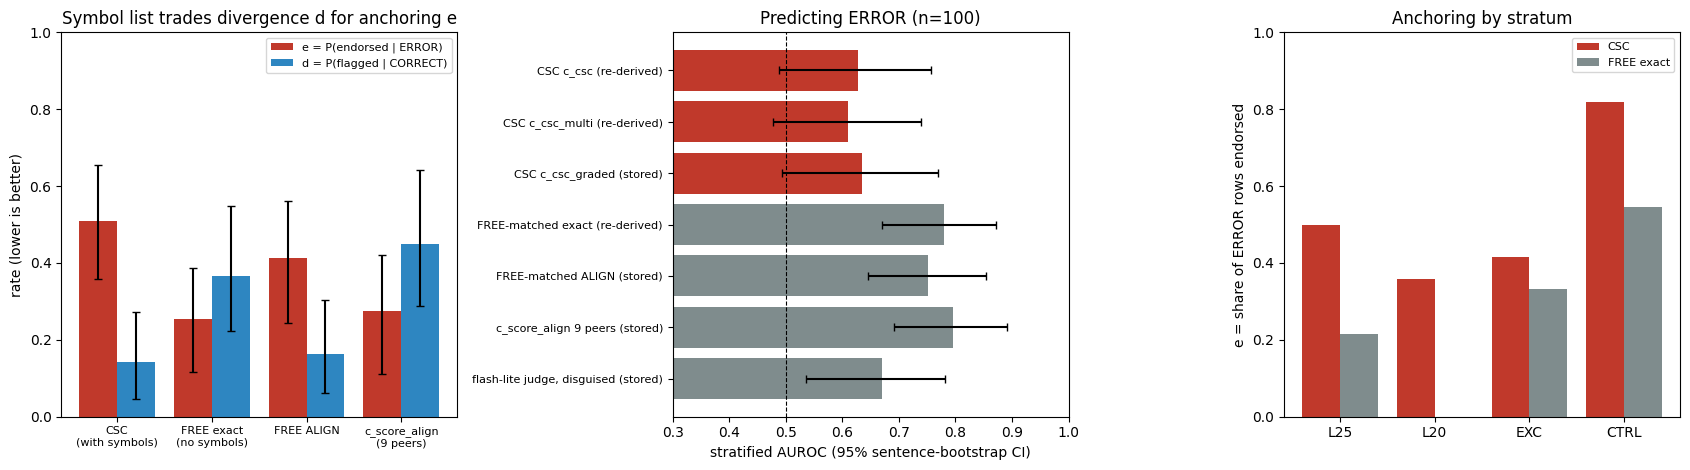

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# (1) e vs d
ax = axes[0]
rules = ["c_csc", "c_free_exact", "c_free_align", "c_score_align"]
names = ["CSC\n(with symbols)", "FREE exact\n(no symbols)", "FREE ALIGN", "c_score_align\n(9 peers)"]
xx = np.arange(len(rules))
ev_ = [ED[r]["e"] for r in rules]; dv_ = [ED[r]["d"] for r in rules]
eerr = np.array([[ED[r]["e"] - ED[r]["e_ci"][0], ED[r]["e_ci"][1] - ED[r]["e"]] for r in rules]).T
derr = np.array([[ED[r]["d"] - ED[r]["d_ci"][0], ED[r]["d_ci"][1] - ED[r]["d"]] for r in rules]).T
ax.bar(xx - 0.2, ev_, 0.4, yerr=eerr, capsize=3, label="e = P(endorsed | ERROR)", color="#c0392b")
ax.bar(xx + 0.2, dv_, 0.4, yerr=derr, capsize=3, label="d = P(flagged | CORRECT)", color="#2e86c1")
ax.set_xticks(xx); ax.set_xticklabels(names, fontsize=8); ax.set_ylim(0, 1); ax.set_ylabel("rate (lower is better)")
ax.set_title("Symbol list trades divergence d for anchoring e"); ax.legend(fontsize=8)

# (2) stratified AUROC with CIs
ax = axes[1]
cols = list(SCORES)
pts = [M[c]["point"] for c in cols]
err = np.array([[M[c]["point"] - M[c]["ci"][0], M[c]["ci"][1] - M[c]["point"]] for c in cols]).T
colors = ["#c0392b" if c.startswith("c_csc") else "#7f8c8d" for c in cols]
ax.barh(range(len(cols)), pts, xerr=err, color=colors, capsize=3)
ax.set_yticks(range(len(cols))); ax.set_yticklabels([SCORES[c] for c in cols], fontsize=8)
ax.axvline(0.5, ls="--", c="k", lw=0.8); ax.set_xlim(0.3, 1.0); ax.invert_yaxis()
ax.set_xlabel("stratified AUROC (95% sentence-bootstrap CI)"); ax.set_title(f"Predicting ERROR (n={len(P)})")

# (3) endorsement of ERROR rows by stratum
ax = axes[2]
strata = ["L25", "L20", "EXC", "CTRL"]
e_csc = [P[(P.stratum == s) & (P.y == 1)].en_c_csc.mean() for s in strata]
e_free = [P[(P.stratum == s) & (P.y == 1)].en_c_free_exact.mean() for s in strata]
xs = np.arange(len(strata))
ax.bar(xs - 0.2, e_csc, 0.4, label="CSC", color="#c0392b"); ax.bar(xs + 0.2, e_free, 0.4, label="FREE exact", color="#7f8c8d")
ax.set_xticks(xs); ax.set_xticklabels(strata); ax.set_ylim(0, 1); ax.set_ylabel("e = share of ERROR rows endorsed")
ax.set_title("Anchoring by stratum"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### An anchoring example

Below are ERROR rows that **all** CSC peers endorsed (`c_csc = 0`) but that the FREE peers, which never saw the candidate's symbols, rejected. Given the candidate's vocabulary, the peers reproduced the candidate's mistake.

In [20]:
anch = P[(P.y == 1) & (P.c_csc == 0) & (P.c_free_exact > 0.5)]
print(f"{len(anch)} ERROR rows fully endorsed by CSC peers but rejected by FREE peers")
byk = {x["row_key"]: x for x in EX}
for rk in anch.row_key.head(3):
    x = byk[rk]
    print("=" * 100)
    print("TEXT      :", x["text"])
    print("CANDIDATE :", x["candidate_fol"], f"  [ERROR; ops={x['error_ops']}]")
    for p in x["csc_peers"]:
        print(f"  CSC  {p['model'][:24]:24s}:", p["fol"])
    for p in x["free_peers"]:
        print(f"  FREE {p['model'][:24]:24s}:", p["fol"])

12 ERROR rows fully endorsed by CSC peers but rejected by FREE peers
TEXT      : All people who regularly drink coffee are dependent on caffeine.
CANDIDATE : ∀x (Person(x) ∧ RegularlyDrink(x, coffee) → DependentOn(x, caffeine))   [ERROR; ops=['DROP']]
  CSC  deepseek/deepseek-v3.2  : ∀x (Person(x) ∧ RegularlyDrink(x, coffee) → DependentOn(x, caffeine))
  CSC  openai/gpt-4.1-mini     : ∀x (Person(x) ∧ RegularlyDrink(x, coffee) → DependentOn(x, caffeine))
  CSC  qwen/qwen3-235b-a22b-250: ∀x (Person(x) ∧ RegularlyDrink(x, coffee) → DependentOn(x, caffeine))
  FREE deepseek/deepseek-v3.2  : ∀x (Person(x) ∧ RegularlyDrink(x, coffee) → DependentOn(x, caffeine))
  FREE openai/gpt-4.1-mini     : ∀x ((Person(x) ∧ RegularlyDrinks(x, coffee)) → DependentOn(x, caffeine))
  FREE qwen/qwen3-235b-a22b-250: ∀x (Person(x) ∧ RegularlyDrinks(x, coffee) → DependentOn(x, caffeine))
TEXT      : If someone in our family is a scientist, then they are an adult.
CANDIDATE : ∀x (Scientist(x) ∧ InFamily(x) → Adul

## Takeaway

The direction of the effect replicates on this 100-row subset, though the CIs are wider than on the full set. On the full PRIMARY set of 354 rows, the paired Δ strat AUROC of CSC vs FREE exact is −0.156 [−0.290, −0.031]. Giving peers the candidate's own symbol list **does not** fix consensus-based gold-free checking of NL→FOL output:
- **what it gains:** fewer false alarms on correct candidates (lower d);
- **what it costs:** much more anchoring into the candidate's errors (higher e). This is concentrated in meaning-rename and added/dropped-condition errors.

The artifact's recommendation for iteration 5 is to fall back to the frozen `c_score_align` + `p_peer_text` and **not** to adopt CSC.

To reproduce the full run, set `N_EXAMPLES` to the full 354 PRIMARY rows, taking the rows from the artifact's `results/per_item_csc_E.jsonl`, and keep `N_BOOT = 2000`.